In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from matplotlib import pyplot as plt

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('/content/drive/MyDrive/UC_Davis_Project/IMDB_data/clean_datasets/ready_to_used.csv')

In [10]:
df.head(5)

,original_title,popularity,runtime,averageRating,release_year,release_month,num_critic_for_reviews,director_facebook_likes,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,num_user_for_reviews,movie_facebook_likes,Genre_first_values,budget_adjusted
0,Hot Tub Time Machine 2,6.575393,93.0,5.0,2015.0,2.0,107.0,38.0,3000.0,837.0,390.0,96.0,0,Comedy,1.833018e+07
1,The Princess Diaries 2: Royal Engagement,8.248895,113.0,5.9,2004.0,8.0,77.0,0.0,11000.0,1000.0,995.0,152.0,1000,Comedy,6.355883e+07
2,Whiplash,44.775274,105.0,8.5,2014.0,10.0,535.0,141.0,24000.0,970.0,535.0,731.0,129000,Drama,4.325815e+06
3,The Possession,7.286477,92.0,5.9,2012.0,8.0,264.0,30.0,941.0,459.0,309.0,162.0,17000,Horror,1.892281e+07
4,The Possession,7.286477,92.0,5.9,2012.0,8.0,264.0,30.0,941.0,459.0,309.0,162.0,17000,Horror,1.892281e+07


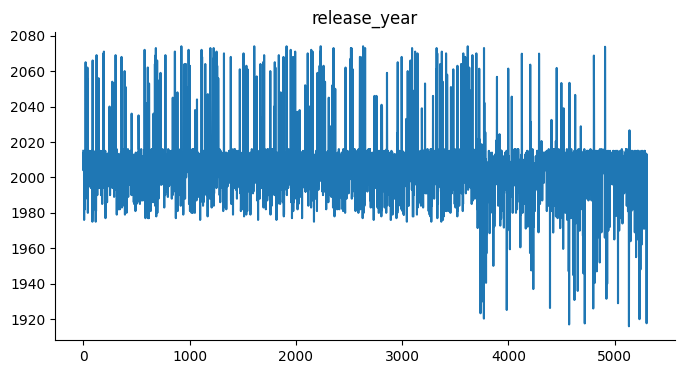

In [11]:
df['release_year'].plot(kind='line', figsize=(8, 4), title='release_year')
plt.gca().spines[['top', 'right']].set_visible(False)

In [12]:
# prompt: Using dataframe df: removed the year >= 2025. and clean the year data is interger.

# Filter out rows where 'release_year' is greater than or equal to 2025
df = df[df['release_year'] < 2025]
# Convert 'release_year' to integer type
df['release_year'] = df['release_year'].astype(int)

<ipython-input-12-e0b526541327>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_year'] = df['release_year'].astype(int)


In [13]:
# prompt: Using dataframe df: check year range again and give the table of max and min year and year distribution

# Display the minimum and maximum values of the 'release_year' column
print("Min Release Year:", df['release_year'].min())
print("Max Release Year:", df['release_year'].max())

# Display the distribution of values in the 'release_year' column
print("\nRelease Year Distribution:")
print(df['release_year'].value_counts().sort_index())

Min Release Year: 1916
Max Release Year: 2024

Release Year Distribution:
release_year
1916      1
1917      3
1920      2
1923      1
1925      1
       ... 
2016    126
2018      1
2020      4
2021      2
2024      1
Name: count, Length: 79, dtype: int64


In [14]:
df.columns.tolist()

['original_title',
 'popularity',
 'runtime',
 'averageRating',
 'release_year',
 'release_month',
 'num_critic_for_reviews',
 'director_facebook_likes',
 'actor_1_facebook_likes',
 'actor_2_facebook_likes',
 'actor_3_facebook_likes',
 'num_user_for_reviews',
 'movie_facebook_likes',
 'Genre_first_values',
 'budget_adjusted']

In [15]:
features = []
features = df.columns.tolist()

In [16]:
features

['original_title',
 'popularity',
 'runtime',
 'averageRating',
 'release_year',
 'release_month',
 'num_critic_for_reviews',
 'director_facebook_likes',
 'actor_1_facebook_likes',
 'actor_2_facebook_likes',
 'actor_3_facebook_likes',
 'num_user_for_reviews',
 'movie_facebook_likes',
 'Genre_first_values',
 'budget_adjusted']

In [17]:
# list all feature's type

for feature in features:
  print(f"{feature}: {df[feature].dtype}")

original_title: object
popularity: float64
runtime: float64
averageRating: float64
release_year: int64
release_month: float64
num_critic_for_reviews: float64
director_facebook_likes: float64
actor_1_facebook_likes: float64
actor_2_facebook_likes: float64
actor_3_facebook_likes: float64
num_user_for_reviews: float64
movie_facebook_likes: int64
Genre_first_values: object
budget_adjusted: float64


In [18]:
# remove original_title from features

features.remove('original_title')
features

['popularity',
 'runtime',
 'averageRating',
 'release_year',
 'release_month',
 'num_critic_for_reviews',
 'director_facebook_likes',
 'actor_1_facebook_likes',
 'actor_2_facebook_likes',
 'actor_3_facebook_likes',
 'num_user_for_reviews',
 'movie_facebook_likes',
 'Genre_first_values',
 'budget_adjusted']

In [19]:
# Transform Genre_first_values from object to numerial number
df = pd.get_dummies( df,
    columns=['Genre_first_values'],
    prefix='Genre',
    drop_first=False,
    dtype='uint8'
)

In [20]:
df.head(5)

,original_title,popularity,runtime,averageRating,release_year,release_month,num_critic_for_reviews,director_facebook_likes,actor_1_facebook_likes,actor_2_facebook_likes,...,Genre_Foreign,Genre_History,Genre_Horror,Genre_Music,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,Hot Tub Time Machine 2,6.575393,93.0,5.0,2015,2.0,107.0,38.0,3000.0,837.0,...,0,0,0,0,0,0,0,0,0,0
1,The Princess Diaries 2: Royal Engagement,8.248895,113.0,5.9,2004,8.0,77.0,0.0,11000.0,1000.0,...,0,0,0,0,0,0,0,0,0,0
2,Whiplash,44.775274,105.0,8.5,2014,10.0,535.0,141.0,24000.0,970.0,...,0,0,0,0,0,0,0,0,0,0
3,The Possession,7.286477,92.0,5.9,2012,8.0,264.0,30.0,941.0,459.0,...,0,0,1,0,0,0,0,0,0,0
4,The Possession,7.286477,92.0,5.9,2012,8.0,264.0,30.0,941.0,459.0,...,0,0,1,0,0,0,0,0,0,0


In [21]:
df.columns.tolist()

['original_title',
 'popularity',
 'runtime',
 'averageRating',
 'release_year',
 'release_month',
 'num_critic_for_reviews',
 'director_facebook_likes',
 'actor_1_facebook_likes',
 'actor_2_facebook_likes',
 'actor_3_facebook_likes',
 'num_user_for_reviews',
 'movie_facebook_likes',
 'budget_adjusted',
 'Genre_Action',
 'Genre_Adventure',
 'Genre_Animation',
 'Genre_Comedy',
 'Genre_Crime',
 'Genre_Documentary',
 'Genre_Drama',
 'Genre_Family',
 'Genre_Fantasy',
 'Genre_Foreign',
 'Genre_History',
 'Genre_Horror',
 'Genre_Music',
 'Genre_Mystery',
 'Genre_Romance',
 'Genre_Science Fiction',
 'Genre_Thriller',
 'Genre_War',
 'Genre_Western']

In [22]:
df.describe()

,popularity,runtime,averageRating,release_year,release_month,num_critic_for_reviews,director_facebook_likes,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Genre_Foreign,Genre_History,Genre_Horror,Genre_Music,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,...,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,15.883181,119.563451,6.396829,2003.553924,7.761171,149.850131,673.155211,6890.811337,1761.837960,689.459595,...,0.000196,0.005676,0.067919,0.005676,0.008221,0.023684,0.022901,0.043648,0.005676,0.003915
std,11.060057,23.984604,1.082614,10.851496,3.141605,130.130573,2741.503404,15074.704174,4165.521462,1762.711785,...,0.013990,0.075134,0.251632,0.075134,0.090304,0.152077,0.149602,0.204332,0.075134,0.062451
min,0.044561,46.000000,1.300000,1916.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.127392,100.000000,5.800000,1999.000000,6.000000,53.000000,6.000000,640.000000,306.000000,141.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.928661,115.000000,6.500000,2006.000000,8.254106,118.000000,49.000000,1000.000000,625.000000,393.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,20.404260,135.588378,7.200000,2011.000000,10.041006,210.000000,212.000000,11000.000000,936.000000,650.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45.177273,174.115874,9.500000,2024.000000,12.000000,813.000000,23000.000000,640000.000000,137000.000000,23000.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [75]:
# using copy reference to run
df_proc = df.copy()
df_proc.head(5)

,original_title,popularity,runtime,averageRating,release_year,release_month,num_critic_for_reviews,director_facebook_likes,actor_1_facebook_likes,actor_2_facebook_likes,...,Genre_Foreign,Genre_History,Genre_Horror,Genre_Music,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,Hot Tub Time Machine 2,6.575393,93.0,5.0,2015,2.0,107.0,38.0,3000.0,837.0,...,0,0,0,0,0,0,0,0,0,0
1,The Princess Diaries 2: Royal Engagement,8.248895,113.0,5.9,2004,8.0,77.0,0.0,11000.0,1000.0,...,0,0,0,0,0,0,0,0,0,0
2,Whiplash,44.775274,105.0,8.5,2014,10.0,535.0,141.0,24000.0,970.0,...,0,0,0,0,0,0,0,0,0,0
3,The Possession,7.286477,92.0,5.9,2012,8.0,264.0,30.0,941.0,459.0,...,0,0,1,0,0,0,0,0,0,0
4,The Possession,7.286477,92.0,5.9,2012,8.0,264.0,30.0,941.0,459.0,...,0,0,1,0,0,0,0,0,0,0


In [76]:
# remove original_title.
df_proc = df_proc.drop(columns=['original_title'], errors='ignore')

In [77]:
X = df_proc.drop(columns=['averageRating'])
y = df_proc['averageRating'].astype(float)

In [78]:
# Scale my features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [79]:
# Fit as linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

LinearRegression()

In [80]:
# extract and sort coefficient based on the important rate
coefs = pd.Series(lr.coef_, index=X.columns).abs().sort_values()

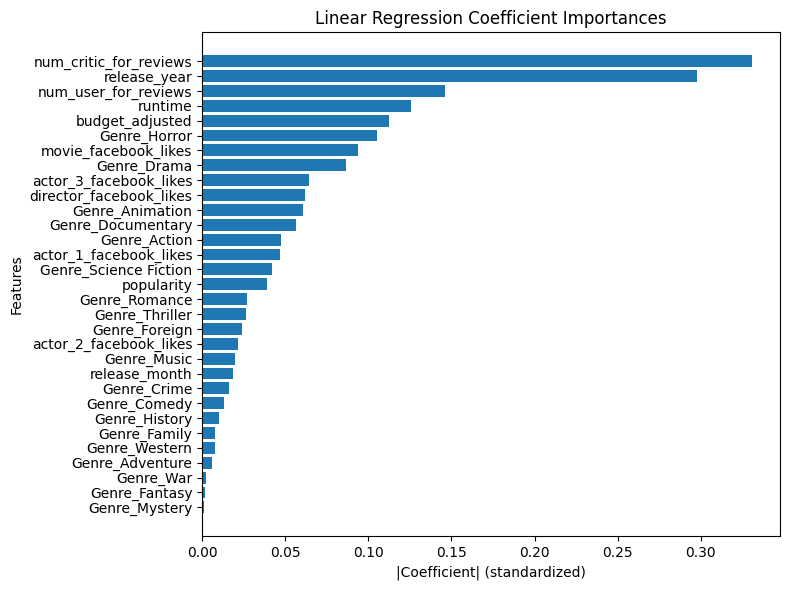

In [81]:
plt.figure(figsize=(8, 6))
plt.barh(coefs.index, coefs.values)
plt.title('Linear Regression Coefficient Importances')
plt.xlabel('|Coefficient| (standardized)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [83]:
# prompt: I wanna cutoff the coefs < 0.05. and collection the features are the rest

important_features_select = coefs[coefs.values >= 0.05].index.tolist()
print("Features with absolute coefficient >= 0.05:")
important_features_select

Features with absolute coefficient >= 0.05:


['Genre_Documentary',
 'Genre_Animation',
 'director_facebook_likes',
 'actor_3_facebook_likes',
 'Genre_Drama',
 'movie_facebook_likes',
 'Genre_Horror',
 'budget_adjusted',
 'runtime',
 'num_user_for_reviews',
 'release_year',
 'num_critic_for_reviews']

In [84]:
# Training model. Using linear-regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [85]:
all_features = important_features_select.copy()

In [86]:
# 3. SPLIT X/y and cast to float64
X = df_proc[all_features].astype('float64')
y = df_proc['averageRating'].astype('float64')

In [91]:
X.head(1)

,Genre_Documentary,Genre_Animation,director_facebook_likes,actor_3_facebook_likes,Genre_Drama,movie_facebook_likes,Genre_Horror,budget_adjusted,runtime,num_user_for_reviews,release_year,num_critic_for_reviews
0,0.0,0.0,38.0,390.0,0.0,0.0,0.0,1.833018e+07,93.0,96.0,2015.0,107.0


In [92]:
y.head(1)

,averageRating
0,5.0


In [37]:
from sklearn.model_selection import train_test_split

In [99]:
# 20 for test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [100]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [101]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = lr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"R²:  {r2_score(y_test, y_pred):.3f}")

MSE: 0.840
R²:  0.229


Since the MSE  =  0.84 and R^2 = 0.23.

This score can confiremed that the features vs rating is not linearly.